In [20]:
#load all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score
# Load the data
wine_quality_data_frame = pd.read_csv('../data/winequality-red.csv')

In [21]:
# Separate features and target
X = wine_quality_data_frame.drop('quality', axis=1)
y = wine_quality_data_frame['quality']

# Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
from sklearn.neural_network import MLPClassifier

# Initialize the Neural Network
# hidden_layer_sizes=(10, 10) means 2 layers with 10 neurons each
neural_network_mlp = MLPClassifier(hidden_layer_sizes=(10, 10), 
                    activation='relu', 
                    solver='adam', 
                    max_iter=1000, 
                    random_state=42)

# Train the model using scaled data
neural_network_mlp.fit(X_train_scaled, y_train)

# Make predictions
y_predicted_neural_network_mlp = neural_network_mlp.predict(X_test_scaled)

# Calculate the metrics
accuracy_of_the_neural_net_model = accuracy_score(y_test, y_predicted_neural_network_mlp)
precision_of_the_neural_net_model = precision_score(y_test, y_predicted_neural_network_mlp, average='weighted')
recall_of_the_neural_net_model = recall_score(y_test, y_predicted_neural_network_mlp, average='weighted')
f1_score_of_the_neural_net_model = f1_score(y_test, y_predicted_neural_network_mlp, average='weighted')

# # Calculate ROC-AUC 
# roc_auc = roc_auc_score(y_test, y_predicted_neural_network_mlp)

# Print the results
print(f"Accuracy:  {accuracy_of_the_neural_net_model:.4f}")
print(f"Precision: {precision_of_the_neural_net_model:.4f}")
print(f"Recall:    {recall_of_the_neural_net_model:.4f}")
print(f"F1-score:  {f1_score_of_the_neural_net_model:.4f}")
# print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.5844
Precision: 0.5556
Recall:    0.5844
F1-score:  0.5669


c:\Users\zaint\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\zaint\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


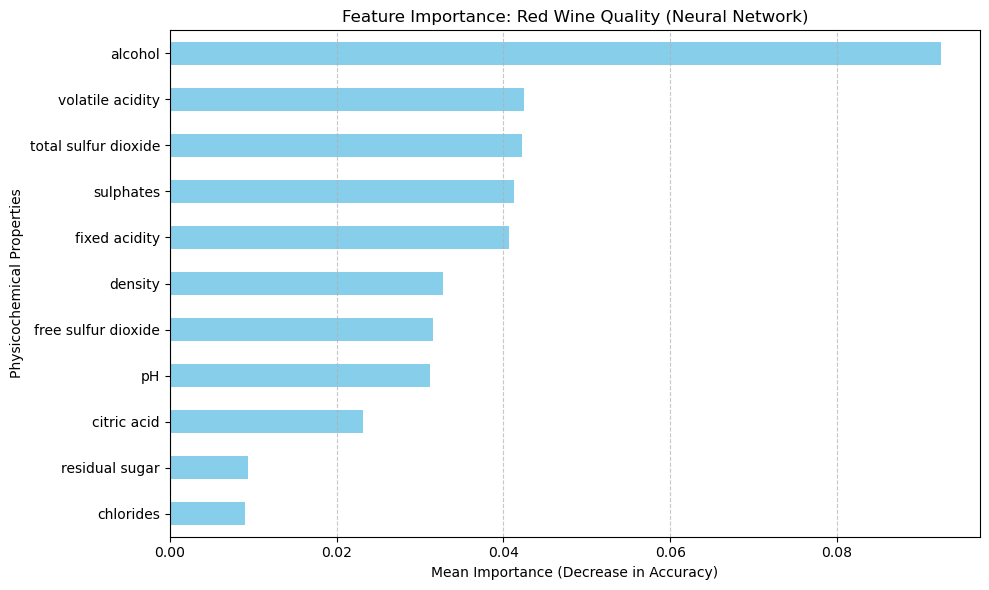

In [23]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

# 1. Calculate Permutation Importance for your Neural Network
# This measures how much the model's accuracy drops when a feature is shuffled
result = permutation_importance(
    neural_network_mlp, 
    X_test_scaled, 
    y_test, 
    n_repeats=10, 
    random_state=42
)

# 2. Organize the data for plotting
# X.columns contains: fixed acidity, volatile acidity, citric acid, pH, alcohol, etc.
feature_importance = pd.Series(
    result.importances_mean, 
    index=X.columns
).sort_values(ascending=True)

# 3. Create the Visualization
plt.figure(figsize=(10, 6))
feature_importance.plot(kind='barh', color='skyblue')

plt.title("Feature Importance: Red Wine Quality (Neural Network)")
plt.xlabel("Mean Importance (Decrease in Accuracy)")
plt.ylabel("Physicochemical Properties")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()